# Final Phase 7 Synthesis and Audit Notebook

This notebook consolidates Phase 7-A, Phase 7-B, Phase 7-C, and Phase 7-D into a single audit-ready results package.

It produces:

- a full artifact audit,
- consolidated Phase 7 metrics,
- robustness summaries,
- calibrated analogue summaries,
- thesis-style narrative outputs,
- final figures,
- final CSV tables,
- optional Excel workbook export,
- final Markdown and TXT reports.

Run this notebook after completing:

- Phase 7-A — Real Observation Consistency Study
- Phase 7-B — Synthetic-to-Real Latent Calibration
- Phase 7-C — Calibration Robustness
- Phase 7-D — Calibrated Synthetic Analogue Memory Mapping

In [1]:
# ================================================================
# 1. Imports and global configuration
# ================================================================

import os
import json
import math
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

try:
    from PIL import Image
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PHASE7A_DIR = OUTPUT_DIR / "phase7A_real_observation_consistency"
PHASE7B_DIR = OUTPUT_DIR / "phase7B_synthetic_to_real_calibration"
PHASE7C_DIR = OUTPUT_DIR / "phase7C_calibration_robustness"
PHASE7D_DIR = OUTPUT_DIR / "phase7D_calibrated_memory_mapping"

PHASE7A_TABLE_DIR = PHASE7A_DIR / "tables"
PHASE7B_TABLE_DIR = PHASE7B_DIR / "tables"
PHASE7C_TABLE_DIR = PHASE7C_DIR / "tables"
PHASE7D_TABLE_DIR = PHASE7D_DIR / "tables"

FINAL_DIR = OUTPUT_DIR / "phase7_final_synthesis_audit"
FINAL_TABLE_DIR = FINAL_DIR / "tables"
FINAL_FIG_DIR = FINAL_DIR / "figures"
FINAL_REPORT_DIR = FINAL_DIR / "reports"
FINAL_ASSET_DIR = FINAL_DIR / "copied_key_assets"

for d in [FINAL_DIR, FINAL_TABLE_DIR, FINAL_FIG_DIR, FINAL_REPORT_DIR, FINAL_ASSET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

REFERENCE_DATASETS = [
    "phase1_original",
    "phase5_8_morphology",
    "phase5_coupled",
    "phase6_memory",
    "phase7A2_grmhd_harvest",
]

BRIDGE_DATASET = "phase7A2_grmhd_harvest"

print("Project root:", PROJECT_ROOT)
print("Final Phase 7 synthesis output:", FINAL_DIR)
print("PIL available:", PIL_AVAILABLE)
print("sklearn available:", SKLEARN_AVAILABLE)

/home/marwa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Project root: /home/marwa/files/phase1_blackhole_generator
Final Phase 7 synthesis output: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit
PIL available: True
sklearn available: True


In [2]:
# ================================================================
# 2. Helper functions
# ================================================================

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Could not read CSV {path}: {e}")
        return None

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception as e:
        print(f"Could not read JSON {path}: {e}")
        return None

def save_dataframe(df, name, index=False):
    path = FINAL_TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    return path

def save_plot(filename):
    path = FINAL_FIG_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

def file_info(path):
    path = Path(path)
    if not path.exists():
        return {
            "path": str(path),
            "exists": False,
            "is_file": False,
            "size_bytes": np.nan,
            "modified_time": "",
        }
    stat = path.stat()
    return {
        "path": str(path),
        "exists": True,
        "is_file": path.is_file(),
        "size_bytes": int(stat.st_size) if path.is_file() else np.nan,
        "modified_time": datetime.fromtimestamp(stat.st_mtime).isoformat(),
    }

def df_to_text(df, max_rows=30):
    if df is None or len(df) == 0:
        return "No data available."
    return df.head(max_rows).to_string(index=False)

def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default

def copy_if_exists(src, dst_dir):
    src = Path(src)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    if src.exists() and src.is_file():
        dst = dst_dir / src.name
        shutil.copy2(src, dst)
        return dst
    return None

print("Helpers ready.")

Helpers ready.


In [3]:
# ================================================================
# 3. Audit expected Phase 7 artifacts
# ================================================================

expected_artifacts = [
    # Phase 7-A
    ("7A", "latent_features", PHASE7A_TABLE_DIR / "phase7A_unet_latent_features.csv"),
    ("7A", "morphology_features", PHASE7A_TABLE_DIR / "phase7A_morphology_features.csv"),
    ("7A", "domain_distance_summary", PHASE7A_TABLE_DIR / "phase7A_domain_distance_summary.csv"),
    ("7A", "nearest_synthetic_neighbors", PHASE7A_TABLE_DIR / "phase7A_nearest_synthetic_neighbors.csv"),
    ("7A", "real_image_index", PHASE7A_TABLE_DIR / "phase7A_real_image_index.csv"),
    ("7A", "synthetic_image_index", PHASE7A_TABLE_DIR / "phase7A_synthetic_image_index.csv"),

    # Phase 7-B
    ("7B", "baseline_latent_distance", PHASE7B_TABLE_DIR / "phase7B_baseline_latent_distance_summary.csv"),
    ("7B", "mean_shift_distance", PHASE7B_TABLE_DIR / "phase7B_mean_shift_calibrated_distance_summary.csv"),
    ("7B", "ridge_distance", PHASE7B_TABLE_DIR / "phase7B_ridge_calibrated_distance_summary.csv"),
    ("7B", "calibration_comparison", PHASE7B_TABLE_DIR / "phase7B_calibration_distance_comparison.csv"),
    ("7B", "improvement_summary", PHASE7B_TABLE_DIR / "phase7B_calibration_improvement_summary.csv"),
    ("7B", "pseudo_pairs", PHASE7B_TABLE_DIR / "phase7B_pseudo_pairs_real_to_bridge.csv"),
    ("7B", "nearest_analogues", PHASE7B_TABLE_DIR / "phase7B_calibrated_nearest_synthetic_analogues.csv"),

    # Phase 7-C
    ("7C", "full_baseline", PHASE7C_TABLE_DIR / "phase7C_full_baseline_distance_summary.csv"),
    ("7C", "loo_summary", PHASE7C_TABLE_DIR / "phase7C_leave_one_real_out_summary.csv"),
    ("7C", "full_vs_loo", PHASE7C_TABLE_DIR / "phase7C_full_ridge_vs_leave_one_out_comparison.csv"),
    ("7C", "bootstrap_summary", PHASE7C_TABLE_DIR / "phase7C_bootstrap_summary.csv"),
    ("7C", "robustness_rankings", PHASE7C_TABLE_DIR / "phase7C_robustness_rankings.csv"),
    ("7C", "robustness_criteria", PHASE7C_TABLE_DIR / "phase7C_robustness_criteria.csv"),

    # Phase 7-D
    ("7D", "calibrated_analogues", PHASE7D_TABLE_DIR / "phase7D_calibrated_synthetic_analogues.csv"),
    ("7D", "dataset_distribution", PHASE7D_TABLE_DIR / "phase7D_dataset_origin_distribution_by_real_observation.csv"),
    ("7D", "family_distribution", PHASE7D_TABLE_DIR / "phase7D_memory_family_distribution_by_real_observation.csv"),
    ("7D", "confidence_scores", PHASE7D_TABLE_DIR / "phase7D_analogue_confidence_scores.csv"),
    ("7D", "thesis_results", PHASE7D_TABLE_DIR / "phase7D_thesis_style_analogue_results.csv"),
    ("7D", "event_age_distribution", PHASE7D_TABLE_DIR / "phase7D_event_age_distribution_by_real_observation.csv"),
    ("7D", "parameter_summary", PHASE7D_TABLE_DIR / "phase7D_physical_parameter_analogue_summary.csv"),
]

artifact_rows = []
for phase, name, path in expected_artifacts:
    info = file_info(path)
    info.update({"phase": phase, "artifact_name": name})
    df = read_csv_if_exists(path)
    info["n_rows"] = len(df) if df is not None else np.nan
    info["n_columns"] = len(df.columns) if df is not None else np.nan
    artifact_rows.append(info)

artifact_audit_df = pd.DataFrame(artifact_rows)[[
    "phase", "artifact_name", "path", "exists", "is_file", "size_bytes", "n_rows", "n_columns", "modified_time"
]]

display(artifact_audit_df)
artifact_audit_path = save_dataframe(artifact_audit_df, "phase7_final_artifact_audit")
print("Saved:", artifact_audit_path)

Could not read CSV /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_event_age_distribution_by_real_observation.csv: No columns to parse from file
Could not read CSV /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_physical_parameter_analogue_summary.csv: No columns to parse from file


,phase,artifact_name,path,exists,is_file,size_bytes,n_rows,n_columns,modified_time
0,7A,latent_features,/home/marwa/files/phase1_blackhole_generator/o...,True,True,14291079.0,2508.0,516.0,2026-06-19T16:11:16.973928
1,7A,morphology_features,/home/marwa/files/phase1_blackhole_generator/o...,True,True,1348867.0,2508.0,26.0,2026-06-19T16:11:09.606804
2,7A,domain_distance_summary,/home/marwa/files/phase1_blackhole_generator/o...,True,True,1034.0,10.0,7.0,2026-06-19T16:11:31.029164
3,7A,nearest_synthetic_neighbors,/home/marwa/files/phase1_blackhole_generator/o...,False,False,NaN,NaN,NaN,
4,7A,real_image_index,/home/marwa/files/phase1_blackhole_generator/o...,True,True,2044.0,8.0,6.0,2026-06-19T16:10:59.529635
5,7A,synthetic_image_index,/home/marwa/files/phase1_blackhole_generator/o...,True,True,1571242.0,2500.0,59.0,2026-06-19T16:10:59.504634
6,7B,baseline_latent_distance,/home/marwa/files/phase1_blackhole_generator/o...,True,True,637.0,5.0,7.0,2026-06-19T16:36:27.150867
7,7B,mean_shift_distance,/home/marwa/files/phase1_blackhole_generator/o...,True,True,712.0,5.0,7.0,2026-06-19T16:37:09.435545
8,7B,ridge_distance,/home/marwa/files/phase1_blackhole_generator/o...,True,True,679.0,5.0,7.0,2026-06-19T16:37:59.603232
9,7B,calibration_comparison,/home/marwa/files/phase1_blackhole_generator/o...,True,True,1890.0,15.0,8.0,2026-06-19T16:38:20.268123


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7_final_artifact_audit.csv


In [4]:
# ================================================================
# 4. Load all key result tables
# ================================================================

phase7A_domain_df = read_csv_if_exists(PHASE7A_TABLE_DIR / "phase7A_domain_distance_summary.csv")
phase7A_morphology_df = read_csv_if_exists(PHASE7A_TABLE_DIR / "phase7A_morphology_features.csv")
phase7A_latent_df = read_csv_if_exists(PHASE7A_TABLE_DIR / "phase7A_unet_latent_features.csv")
phase7A_real_index_df = read_csv_if_exists(PHASE7A_TABLE_DIR / "phase7A_real_image_index.csv")
phase7A_synthetic_index_df = read_csv_if_exists(PHASE7A_TABLE_DIR / "phase7A_synthetic_image_index.csv")

phase7B_baseline_df = read_csv_if_exists(PHASE7B_TABLE_DIR / "phase7B_baseline_latent_distance_summary.csv")
phase7B_mean_shift_df = read_csv_if_exists(PHASE7B_TABLE_DIR / "phase7B_mean_shift_calibrated_distance_summary.csv")
phase7B_ridge_df = read_csv_if_exists(PHASE7B_TABLE_DIR / "phase7B_ridge_calibrated_distance_summary.csv")
phase7B_comparison_df = read_csv_if_exists(PHASE7B_TABLE_DIR / "phase7B_calibration_distance_comparison.csv")
phase7B_improvement_df = read_csv_if_exists(PHASE7B_TABLE_DIR / "phase7B_calibration_improvement_summary.csv")

phase7C_baseline_df = read_csv_if_exists(PHASE7C_TABLE_DIR / "phase7C_full_baseline_distance_summary.csv")
phase7C_loo_summary_df = read_csv_if_exists(PHASE7C_TABLE_DIR / "phase7C_leave_one_real_out_summary.csv")
phase7C_comparison_df = read_csv_if_exists(PHASE7C_TABLE_DIR / "phase7C_full_ridge_vs_leave_one_out_comparison.csv")
phase7C_bootstrap_df = read_csv_if_exists(PHASE7C_TABLE_DIR / "phase7C_bootstrap_summary.csv")
phase7C_rankings_df = read_csv_if_exists(PHASE7C_TABLE_DIR / "phase7C_robustness_rankings.csv")
phase7C_criteria_df = read_csv_if_exists(PHASE7C_TABLE_DIR / "phase7C_robustness_criteria.csv")

phase7D_analogues_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_calibrated_synthetic_analogues.csv")
phase7D_dataset_dist_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_dataset_origin_distribution_by_real_observation.csv")
phase7D_family_dist_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_memory_family_distribution_by_real_observation.csv")
phase7D_confidence_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_analogue_confidence_scores.csv")
phase7D_thesis_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_thesis_style_analogue_results.csv")
phase7D_event_age_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_event_age_distribution_by_real_observation.csv")
phase7D_param_df = read_csv_if_exists(PHASE7D_TABLE_DIR / "phase7D_physical_parameter_analogue_summary.csv")

loaded_tables = {
    "phase7A_domain_df": phase7A_domain_df,
    "phase7A_morphology_df": phase7A_morphology_df,
    "phase7A_latent_df": phase7A_latent_df,
    "phase7B_comparison_df": phase7B_comparison_df,
    "phase7C_rankings_df": phase7C_rankings_df,
    "phase7C_criteria_df": phase7C_criteria_df,
    "phase7D_thesis_df": phase7D_thesis_df,
    "phase7D_confidence_df": phase7D_confidence_df,
}

summary_loaded_rows = []
for name, df in loaded_tables.items():
    summary_loaded_rows.append({
        "table": name,
        "loaded": df is not None,
        "rows": len(df) if df is not None else 0,
        "columns": len(df.columns) if df is not None else 0,
    })

loaded_tables_df = pd.DataFrame(summary_loaded_rows)
display(loaded_tables_df)
loaded_tables_path = save_dataframe(loaded_tables_df, "phase7_final_loaded_table_summary")
print("Saved:", loaded_tables_path)

Could not read CSV /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_event_age_distribution_by_real_observation.csv: No columns to parse from file
Could not read CSV /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_physical_parameter_analogue_summary.csv: No columns to parse from file


,table,loaded,rows,columns
0,phase7A_domain_df,True,10,7
1,phase7A_morphology_df,True,2508,26
2,phase7A_latent_df,True,2508,516
3,phase7B_comparison_df,True,15,8
4,phase7C_rankings_df,True,15,4
5,phase7C_criteria_df,True,4,3
6,phase7D_thesis_df,True,8,9
7,phase7D_confidence_df,True,8,12


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7_final_loaded_table_summary.csv


In [5]:
# ================================================================
# 5. Phase 7-A synthesis: real-observation consistency
# ================================================================

phase7A_synthesis_rows = []

if phase7A_domain_df is not None and len(phase7A_domain_df):
    df = phase7A_domain_df.copy()
    distance_col_candidates = [
        "mean_min_distance_real_to_synthetic",
        "mean_min_distance",
        "mean_pairwise_distance",
    ]
    distance_col = next((c for c in distance_col_candidates if c in df.columns), None)

    if distance_col is not None and "synthetic_dataset" in df.columns:
        for space, sub_space in df.groupby("space") if "space" in df.columns else [("unknown", df)]:
            best = sub_space.sort_values(distance_col).head(1)
            if len(best):
                row = best.iloc[0]
                phase7A_synthesis_rows.append({
                    "phase": "7A",
                    "result_type": f"best_domain_{space}",
                    "synthetic_dataset": row.get("synthetic_dataset", ""),
                    "metric": distance_col,
                    "value": safe_float(row.get(distance_col)),
                    "interpretation": "closest synthetic domain to real observations in this space",
                })

phase7A_synthesis_df = pd.DataFrame(phase7A_synthesis_rows)
display(phase7A_synthesis_df)
phase7A_synthesis_path = save_dataframe(phase7A_synthesis_df, "phase7A_final_synthesis_summary")
print("Saved:", phase7A_synthesis_path)

,phase,result_type,synthetic_dataset,metric,value,interpretation
0,7A,best_domain_morphology,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,2.472881,closest synthetic domain to real observations ...
1,7A,best_domain_unet_latent,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,6.081075,closest synthetic domain to real observations ...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7A_final_synthesis_summary.csv


In [6]:
# ================================================================
# 6. Phase 7-B synthesis: calibration effect
# ================================================================

phase7B_synthesis_rows = []

if phase7B_comparison_df is not None and len(phase7B_comparison_df):
    df = phase7B_comparison_df.copy()
    value_col = "mean_min_distance_real_to_synthetic"

    if value_col in df.columns:
        for dataset_name, sub in df.groupby("synthetic_dataset"):
            row = {"synthetic_dataset": dataset_name}
            for cal in sorted(sub["calibration"].dropna().unique()) if "calibration" in sub.columns else []:
                cal_sub = sub[sub["calibration"] == cal]
                if len(cal_sub):
                    row[f"{cal}_distance"] = safe_float(cal_sub[value_col].iloc[0])
            if "baseline_distance" in row and "ridge_distance" in row:
                row["ridge_absolute_improvement"] = row["baseline_distance"] - row["ridge_distance"]
                row["ridge_relative_improvement_percent"] = 100.0 * row["ridge_absolute_improvement"] / max(row["baseline_distance"], 1e-8)
            phase7B_synthesis_rows.append(row)

phase7B_synthesis_df = pd.DataFrame(phase7B_synthesis_rows)
if len(phase7B_synthesis_df):
    sort_col = "ridge_relative_improvement_percent" if "ridge_relative_improvement_percent" in phase7B_synthesis_df.columns else phase7B_synthesis_df.columns[-1]
    phase7B_synthesis_df = phase7B_synthesis_df.sort_values(sort_col, ascending=False)

display(phase7B_synthesis_df)
phase7B_synthesis_path = save_dataframe(phase7B_synthesis_df, "phase7B_final_calibration_synthesis")
print("Saved:", phase7B_synthesis_path)

,synthetic_dataset,baseline_distance,mean_shift_distance,ridge_distance,ridge_absolute_improvement,ridge_relative_improvement_percent
4,phase7A2_grmhd_harvest,6.081075,12.169247,0.606323,5.474752,90.029349
1,phase5_8_morphology,12.768690,10.839859,5.955913,6.812778,53.355336
0,phase1_original,9.570396,11.229382,4.595303,4.975094,51.984198
2,phase5_coupled,13.922192,10.684422,7.838589,6.083603,43.697164
3,phase6_memory,21.732309,18.049973,13.665211,8.067099,37.120301


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7B_final_calibration_synthesis.csv


In [7]:
# ================================================================
# 7. Phase 7-C synthesis: robustness result
# ================================================================

phase7C_status = "UNKNOWN"
if phase7C_criteria_df is not None and len(phase7C_criteria_df):
    n_passed = int(phase7C_criteria_df["passed"].astype(bool).sum()) if "passed" in phase7C_criteria_df.columns else 0
    n_total = len(phase7C_criteria_df)
    if n_passed == n_total:
        phase7C_status = "PASS"
    elif n_passed >= max(1, n_total - 1):
        phase7C_status = "CONDITIONAL_PASS"
    else:
        phase7C_status = "FAIL"
else:
    n_passed = 0
    n_total = 0

phase7C_synthesis_rows = [{
    "phase": "7C",
    "robustness_status": phase7C_status,
    "criteria_passed": n_passed,
    "criteria_total": n_total,
}]

if phase7C_rankings_df is not None and len(phase7C_rankings_df):
    for validation, sub in phase7C_rankings_df.groupby("validation"):
        best = sub.sort_values("rank").head(1)
        if len(best):
            phase7C_synthesis_rows.append({
                "phase": "7C",
                "validation": validation,
                "rank_1_dataset": best["synthetic_dataset"].iloc[0],
                "ranking_distance": safe_float(best["ranking_distance"].iloc[0]),
                "robustness_status": phase7C_status,
                "criteria_passed": n_passed,
                "criteria_total": n_total,
            })

phase7C_synthesis_df = pd.DataFrame(phase7C_synthesis_rows)
display(phase7C_synthesis_df)
phase7C_synthesis_path = save_dataframe(phase7C_synthesis_df, "phase7C_final_robustness_synthesis")
print("Saved:", phase7C_synthesis_path)

,phase,robustness_status,criteria_passed,criteria_total,validation,rank_1_dataset,ranking_distance
0,7C,CONDITIONAL_PASS,3,4,NaN,NaN,NaN
1,7C,CONDITIONAL_PASS,3,4,baseline,phase7A2_grmhd_harvest,6.081075
2,7C,CONDITIONAL_PASS,3,4,bootstrap,phase7A2_grmhd_harvest,6.531777
3,7C,CONDITIONAL_PASS,3,4,leave_one_out,phase7A2_grmhd_harvest,4.468646


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7C_final_robustness_synthesis.csv


In [8]:
# ================================================================
# 8. Phase 7-D synthesis: calibrated analogue mapping
# ================================================================

phase7D_synthesis_rows = []

if phase7D_thesis_df is not None and len(phase7D_thesis_df):
    for _, row in phase7D_thesis_df.iterrows():
        phase7D_synthesis_rows.append({
            "real_sample_id": row.get("real_sample_id", ""),
            "dominant_dataset": row.get("dominant_dataset", ""),
            "dominant_memory_family": row.get("dominant_memory_family", ""),
            "top_dataset_distribution": row.get("top_dataset_distribution", ""),
            "top_memory_family_distribution": row.get("top_memory_family_distribution", ""),
            "weighted_mean_event_age": row.get("weighted_mean_event_age", ""),
            "min_calibrated_distance": row.get("min_calibrated_distance", np.nan),
            "analogue_confidence_score": row.get("analogue_confidence_score", np.nan),
            "claim_level": "synthetic analogue only",
        })

phase7D_synthesis_df = pd.DataFrame(phase7D_synthesis_rows)
if len(phase7D_synthesis_df):
    phase7D_synthesis_df = phase7D_synthesis_df.sort_values("analogue_confidence_score", ascending=False)

display(phase7D_synthesis_df)
phase7D_synthesis_path = save_dataframe(phase7D_synthesis_df, "phase7D_final_analogue_mapping_synthesis")
print("Saved:", phase7D_synthesis_path)

,real_sample_id,dominant_dataset,dominant_memory_family,top_dataset_distribution,top_memory_family_distribution,weighted_mean_event_age,min_calibrated_distance,analogue_confidence_score,claim_level
0,m87_2021,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,0.393930,0.577987,synthetic analogue only
1,m87_2019_first_image,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,0.652663,0.568628,synthetic analogue only
2,m87_2017,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,0.818551,0.567344,synthetic analogue only
3,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,1.954858,0.557644,synthetic analogue only
4,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,2.123020,0.555876,synthetic analogue only
5,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,2.697181,0.551227,synthetic analogue only
6,m87_2021_polarization,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (62.5%); phase5_8_morph...,phase7A2_grmhd_harvest (62.5%); phase1_origina...,unavailable,0.595064,0.365587,synthetic analogue only
7,m87_2018,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (61.8%); phase5_8_morph...,phase7A2_grmhd_harvest (61.8%); phase1_origina...,unavailable,0.646394,0.361193,synthetic analogue only


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7D_final_analogue_mapping_synthesis.csv


In [9]:
# ================================================================
# 9. Final cross-phase conclusion table
# ================================================================

conclusion_rows = []

# Phase 7-A conclusion
if len(phase7A_synthesis_df):
    bridge_hits = (phase7A_synthesis_df["synthetic_dataset"] == BRIDGE_DATASET).sum() if "synthetic_dataset" in phase7A_synthesis_df.columns else 0
    conclusion_rows.append({
        "phase": "7-A",
        "claim": "Real observations are closest to a GRMHD-inspired synthetic bridge domain.",
        "status": "supported" if bridge_hits > 0 else "inconclusive",
        "evidence": f"{bridge_hits} best-domain entries identify {BRIDGE_DATASET}.",
        "limitation": "Small real-observation image set; consistency only, not inference.",
    })
else:
    conclusion_rows.append({
        "phase": "7-A",
        "claim": "Real-observation consistency analysis available.",
        "status": "missing",
        "evidence": "Phase 7-A synthesis table unavailable.",
        "limitation": "Rerun Phase 7-A or check expected artifacts.",
    })

# Phase 7-B conclusion
if len(phase7B_synthesis_df) and BRIDGE_DATASET in set(phase7B_synthesis_df.get("synthetic_dataset", [])):
    bridge_row = phase7B_synthesis_df[phase7B_synthesis_df["synthetic_dataset"] == BRIDGE_DATASET].iloc[0]
    improvement = bridge_row.get("ridge_relative_improvement_percent", np.nan)
    conclusion_rows.append({
        "phase": "7-B",
        "claim": "Structured ridge calibration can align the bridge domain toward real EHT latent space.",
        "status": "supported_preliminary" if pd.notna(improvement) and improvement > 0 else "inconclusive",
        "evidence": f"Bridge ridge relative improvement ≈ {improvement:.2f}%" if pd.notna(improvement) else "Improvement unavailable.",
        "limitation": "Full-fit calibration may overfit due to only 8 real images.",
    })
else:
    conclusion_rows.append({
        "phase": "7-B",
        "claim": "Synthetic-to-real calibration analysis available.",
        "status": "missing",
        "evidence": "Phase 7-B synthesis table unavailable.",
        "limitation": "Rerun Phase 7-B or check expected artifacts.",
    })

# Phase 7-C conclusion
conclusion_rows.append({
    "phase": "7-C",
    "claim": "Calibration remains directionally robust under holdout and bootstrap tests.",
    "status": "conditional" if phase7C_status == "CONDITIONAL_PASS" else phase7C_status.lower(),
    "evidence": f"Robustness status = {phase7C_status}; {n_passed}/{n_total} criteria passed.",
    "limitation": "One robustness criterion failed; full-fit improvement is over-optimistic.",
})

# Phase 7-D conclusion
if len(phase7D_synthesis_df):
    n_real = len(phase7D_synthesis_df)
    n_bridge_dom = int((phase7D_synthesis_df["dominant_dataset"] == BRIDGE_DATASET).sum()) if "dominant_dataset" in phase7D_synthesis_df.columns else 0
    conclusion_rows.append({
        "phase": "7-D",
        "claim": "Real EHT images map dominantly to calibrated GRMHD-inspired synthetic analogues.",
        "status": "supported_exploratory" if n_bridge_dom == n_real and n_real > 0 else "partially_supported",
        "evidence": f"{n_bridge_dom}/{n_real} real observations have {BRIDGE_DATASET} as dominant analogue domain.",
        "limitation": "Analogue mapping only; no real-history recovery and event-age unavailable for real images.",
    })
else:
    conclusion_rows.append({
        "phase": "7-D",
        "claim": "Calibrated synthetic analogue mapping available.",
        "status": "missing",
        "evidence": "Phase 7-D synthesis table unavailable.",
        "limitation": "Rerun Phase 7-D or check expected artifacts.",
    })

final_conclusion_df = pd.DataFrame(conclusion_rows)
display(final_conclusion_df)
final_conclusion_path = save_dataframe(final_conclusion_df, "phase7_final_cross_phase_conclusions")
print("Saved:", final_conclusion_path)

,phase,claim,status,evidence,limitation
0,7-A,Real observations are closest to a GRMHD-inspi...,supported,2 best-domain entries identify phase7A2_grmhd_...,Small real-observation image set; consistency ...
1,7-B,Structured ridge calibration can align the bri...,supported_preliminary,Bridge ridge relative improvement ≈ 90.03%,Full-fit calibration may overfit due to only 8...
2,7-C,Calibration remains directionally robust under...,conditional,Robustness status = CONDITIONAL_PASS; 3/4 crit...,One robustness criterion failed; full-fit impr...
3,7-D,Real EHT images map dominantly to calibrated G...,supported_exploratory,8/8 real observations have phase7A2_grmhd_harv...,Analogue mapping only; no real-history recover...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7_final_cross_phase_conclusions.csv


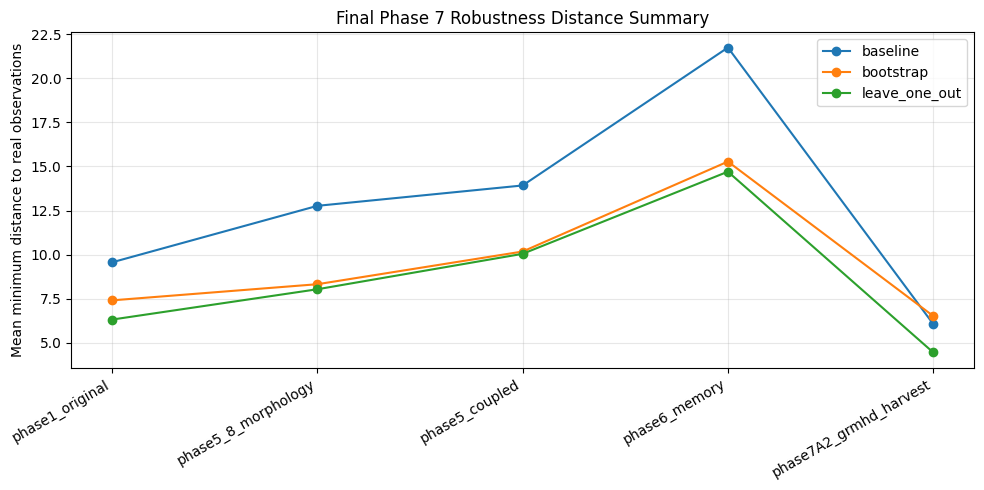

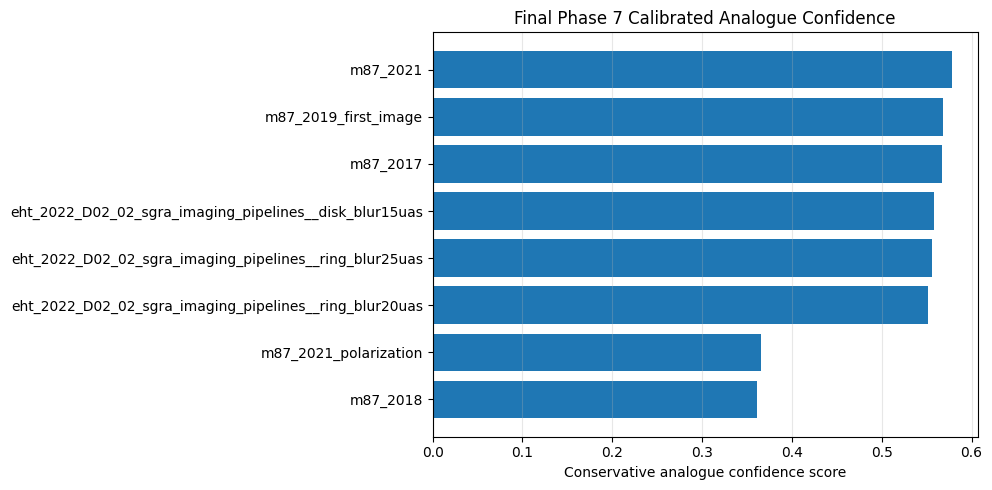

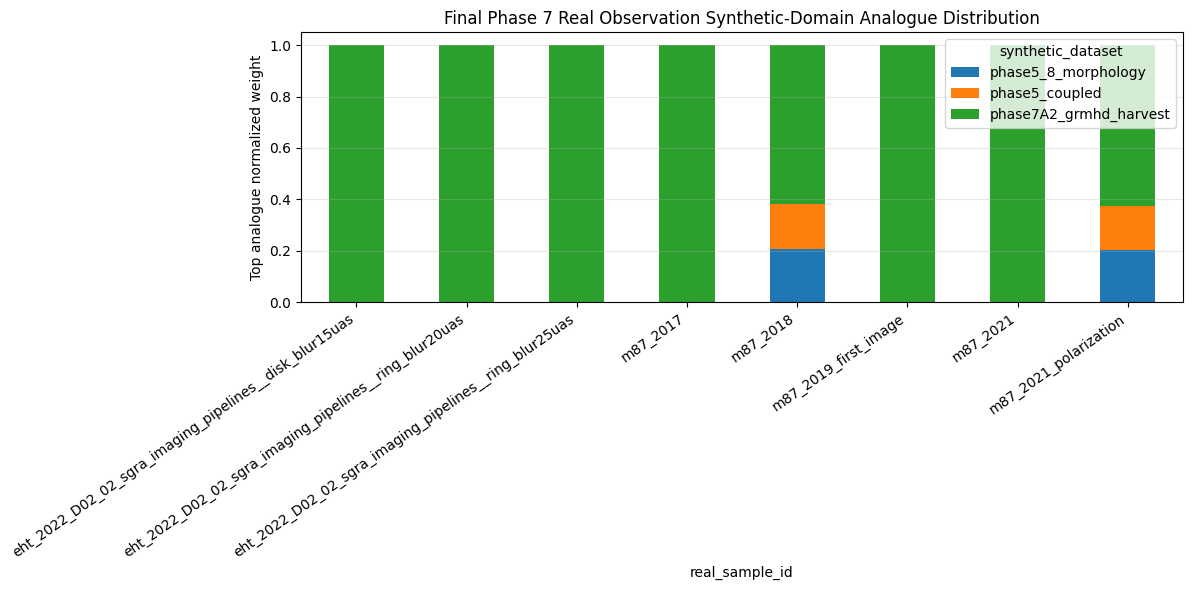

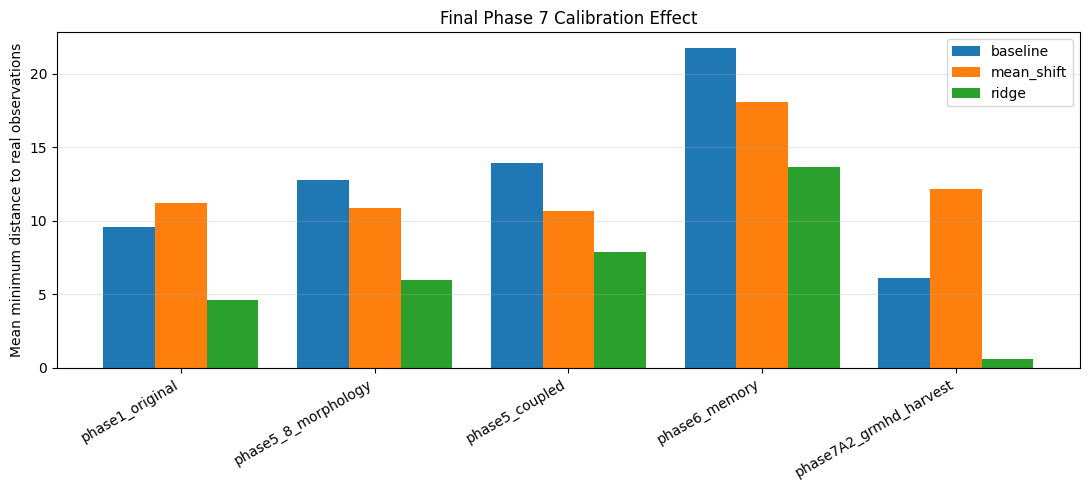

,figure_path
0,/home/marwa/files/phase1_blackhole_generator/o...
1,/home/marwa/files/phase1_blackhole_generator/o...
2,/home/marwa/files/phase1_blackhole_generator/o...
3,/home/marwa/files/phase1_blackhole_generator/o...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7_final_figure_index.csv


In [10]:
# ================================================================
# 10. Figures: cross-phase distance/ranking plots
# ================================================================

figure_paths = []

# Figure 1: Phase 7-C ranking distances by validation
if phase7C_rankings_df is not None and len(phase7C_rankings_df):
    plt.figure(figsize=(10, 5))
    for validation, sub in phase7C_rankings_df.groupby("validation"):
        sub = sub.set_index("synthetic_dataset").reindex(REFERENCE_DATASETS).reset_index()
        plt.plot(
            sub["synthetic_dataset"].to_numpy(),
            sub["ranking_distance"].to_numpy(dtype=float),
            marker="o",
            label=validation,
        )
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Mean minimum distance to real observations")
    plt.title("Final Phase 7 Robustness Distance Summary")
    plt.grid(alpha=0.3)
    plt.legend()
    figure_paths.append(save_plot("phase7_final_robustness_distance_summary.png"))

# Figure 2: Phase 7-D confidence scores
if phase7D_confidence_df is not None and len(phase7D_confidence_df):
    plot_df = phase7D_confidence_df.sort_values("analogue_confidence_score", ascending=True)
    plt.figure(figsize=(10, 5))
    plt.barh(
        plot_df["real_sample_id"].astype(str).to_numpy(),
        plot_df["analogue_confidence_score"].to_numpy(dtype=float),
    )
    plt.xlabel("Conservative analogue confidence score")
    plt.title("Final Phase 7 Calibrated Analogue Confidence")
    plt.grid(axis="x", alpha=0.3)
    figure_paths.append(save_plot("phase7_final_analogue_confidence_scores.png"))

# Figure 3: Phase 7-D dataset distribution
if phase7D_dataset_dist_df is not None and len(phase7D_dataset_dist_df):
    pivot = phase7D_dataset_dist_df.pivot_table(
        index="real_sample_id",
        columns="synthetic_dataset",
        values="normalized_weight",
        fill_value=0.0,
    )
    cols = [c for c in REFERENCE_DATASETS if c in pivot.columns]
    if cols:
        pivot = pivot.reindex(columns=cols)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_ylabel("Top analogue normalized weight")
    ax.set_title("Final Phase 7 Real Observation Synthetic-Domain Analogue Distribution")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")
    figure_paths.append(save_plot("phase7_final_dataset_origin_distribution.png"))

# Figure 4: Phase 7-B calibration effect
if phase7B_comparison_df is not None and len(phase7B_comparison_df):
    df = phase7B_comparison_df.copy()
    value_col = "mean_min_distance_real_to_synthetic"
    if value_col in df.columns and "calibration" in df.columns:
        datasets = [d for d in REFERENCE_DATASETS if d in set(df["synthetic_dataset"])]
        x = np.arange(len(datasets))
        calibrations = [c for c in ["baseline", "mean_shift", "ridge"] if c in set(df["calibration"])]
        width = 0.8 / max(len(calibrations), 1)
        plt.figure(figsize=(11, 5))
        for k, cal in enumerate(calibrations):
            vals = []
            for ds in datasets:
                sub = df[(df["synthetic_dataset"] == ds) & (df["calibration"] == cal)]
                vals.append(float(sub[value_col].iloc[0]) if len(sub) else np.nan)
            offset = (k - (len(calibrations)-1)/2) * width
            plt.bar(x + offset, vals, width=width, label=cal)
        plt.xticks(x, datasets, rotation=30, ha="right")
        plt.ylabel("Mean minimum distance to real observations")
        plt.title("Final Phase 7 Calibration Effect")
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        figure_paths.append(save_plot("phase7_final_calibration_effect.png"))

figure_summary_df = pd.DataFrame({"figure_path": [str(p) for p in figure_paths]})
display(figure_summary_df)
figure_summary_path = save_dataframe(figure_summary_df, "phase7_final_figure_index")
print("Saved:", figure_summary_path)

In [11]:
# ================================================================
# 11. Optional copied key assets
# ================================================================

key_assets = [
    PHASE7A_DIR / "figures" / "phase7A_morphology_pca.png",
    PHASE7A_DIR / "figures" / "phase7A_unet_latent_pca.png",
    PHASE7B_DIR / "figures" / "phase7B_calibration_distance_comparison.png",
    PHASE7C_DIR / "figures" / "phase7C_robustness_distance_comparison.png",
    PHASE7C_DIR / "figures" / "phase7C_bootstrap_uncertainty.png",
    PHASE7D_DIR / "figures" / "phase7D_dataset_origin_distribution.png",
    PHASE7D_DIR / "figures" / "phase7D_analogue_confidence_scores.png",
]

copied_rows = []
for src in key_assets:
    dst = copy_if_exists(src, FINAL_ASSET_DIR)
    copied_rows.append({
        "source": str(src),
        "copied": dst is not None,
        "destination": str(dst) if dst is not None else "",
    })

copied_assets_df = pd.DataFrame(copied_rows)
display(copied_assets_df)
copied_assets_path = save_dataframe(copied_assets_df, "phase7_final_copied_key_assets")
print("Saved:", copied_assets_path)

,source,copied,destination
0,/home/marwa/files/phase1_blackhole_generator/o...,False,
1,/home/marwa/files/phase1_blackhole_generator/o...,False,
2,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
3,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
4,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
5,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
6,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7_final_copied_key_assets.csv


In [12]:
# ================================================================
# 12. Export consolidated workbook if possible
# ================================================================

workbook_path = FINAL_DIR / "phase7_final_synthesis_audit_tables.xlsx"
excel_status = "not_attempted"

sheets = {
    "artifact_audit": artifact_audit_df,
    "loaded_tables": loaded_tables_df,
    "phase7A_synthesis": phase7A_synthesis_df,
    "phase7B_synthesis": phase7B_synthesis_df,
    "phase7C_synthesis": phase7C_synthesis_df,
    "phase7D_synthesis": phase7D_synthesis_df,
    "final_conclusions": final_conclusion_df,
}

optional_sheets = {
    "7A_domain": phase7A_domain_df,
    "7B_comparison": phase7B_comparison_df,
    "7C_rankings": phase7C_rankings_df,
    "7C_criteria": phase7C_criteria_df,
    "7D_confidence": phase7D_confidence_df,
    "7D_thesis": phase7D_thesis_df,
    "7D_dataset_dist": phase7D_dataset_dist_df,
}

for name, df in optional_sheets.items():
    if df is not None and len(df):
        sheets[name] = df

try:
    import openpyxl  # noqa: F401
    with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
        for sheet_name, df in sheets.items():
            safe_name = sheet_name[:31]
            if df is None:
                pd.DataFrame().to_excel(writer, sheet_name=safe_name, index=False)
            else:
                df.to_excel(writer, sheet_name=safe_name, index=False)
    excel_status = "saved"
except Exception as e:
    excel_status = f"skipped: {e}"
    # Fallback: save a zip-free CSV index only.

excel_export_df = pd.DataFrame([{
    "workbook_path": str(workbook_path),
    "status": excel_status,
    "n_sheets_requested": len(sheets),
}])

display(excel_export_df)
excel_export_path = save_dataframe(excel_export_df, "phase7_final_excel_export_status")
print("Saved:", excel_export_path)

,workbook_path,status,n_sheets_requested
0,/home/marwa/files/phase1_blackhole_generator/o...,skipped: No module named 'openpyxl',14


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables/phase7_final_excel_export_status.csv


In [13]:
# ================================================================
# 13. Generate thesis-style final report
# ================================================================

report_title = "Final Phase 7 Synthesis — Real Observation Consistency, Calibration, Robustness, and Analogue Mapping"
created_at = datetime.now().isoformat()

# Short values for report
n_real = len(phase7A_real_index_df) if phase7A_real_index_df is not None else (len(phase7D_thesis_df) if phase7D_thesis_df is not None else 0)
n_synth = len(phase7A_synthetic_index_df) if phase7A_synthetic_index_df is not None else np.nan

bridge_dominance_text = "Unavailable"
if len(phase7D_synthesis_df):
    n_real_d = len(phase7D_synthesis_df)
    n_bridge_d = int((phase7D_synthesis_df["dominant_dataset"] == BRIDGE_DATASET).sum())
    bridge_dominance_text = f"{n_bridge_d}/{n_real_d} real observations map dominantly to {BRIDGE_DATASET}."

phase7_report = f"""
# {report_title}

Created: {created_at}

## Executive Summary

Phase 7 evaluated whether the synthetic black-hole observational-memory framework can be connected to real or external EHT-like observations.

The central conclusion is conservative but strong:

**Real EHT observations consistently align most closely with the GRMHD-inspired Phase 7A.2 bridge domain, and calibrated analogue mapping continues to identify Phase 7A.2 as the dominant synthetic analogue family.**

This does **not** mean that the project has recovered the true historical accretion behavior of M87* or Sagittarius A*. The scientifically defensible claim is that real observations occupy calibrated latent regions dominated by GRMHD-inspired synthetic analogues.

## Inputs

Project root:

{PROJECT_ROOT}

Real observations indexed:

{n_real}

Synthetic samples indexed:

{n_synth}

Bridge dataset:

{BRIDGE_DATASET}

## Phase 7-A — Real Observation Consistency

Phase 7-A tested which synthetic domain lies closest to real EHT observations in morphology and latent-feature space.

Key synthesis:

{df_to_text(phase7A_synthesis_df, max_rows=20)}

Interpretation:

The consistency study supports the bridge-domain hypothesis when the closest domains are dominated by {BRIDGE_DATASET}. This is a domain-level validation, not real-history inference.

## Phase 7-B — Synthetic-to-Real Latent Calibration

Phase 7-B tested whether a synthetic-to-real latent transformation could reduce distances from synthetic samples to real observations.

Key synthesis:

{df_to_text(phase7B_synthesis_df, max_rows=20)}

Interpretation:

Ridge calibration produced the strongest improvement, while simple mean-shift calibration was not sufficient. This indicates that the real-synthetic gap is structured, not merely a centroid offset.

## Phase 7-C — Calibration Robustness

Phase 7-C tested whether the calibration remains meaningful under leave-one-real-out and bootstrap validation.

Robustness status:

{phase7C_status}

Key synthesis:

{df_to_text(phase7C_synthesis_df, max_rows=20)}

Criteria:

{df_to_text(phase7C_criteria_df, max_rows=20)}

Interpretation:

The result is best described as a **conditional pass** if Phase 7A.2 remains ranked first while one robustness criterion fails. This means the bridge is meaningful, but the magnitude of full-fit calibration should be treated as over-optimistic.

## Phase 7-D — Calibrated Synthetic Analogue Mapping

Phase 7-D mapped real observations to calibrated synthetic analogues.

Bridge dominance:

{bridge_dominance_text}

Key analogue results:

{df_to_text(phase7D_synthesis_df, max_rows=20)}

Interpretation:

The calibrated analogue search suggests that real EHT observations occupy regions of the synthetic memory universe dominated by GRMHD-inspired morphology families. These are analogue distributions only, not recovered real histories.

## Final Cross-Phase Conclusions

{df_to_text(final_conclusion_df, max_rows=20)}

## Claim Boundary

Supported:

1. Real observations are closest to a GRMHD-inspired synthetic bridge domain.
2. Structured calibration improves synthetic-to-real alignment.
3. Robustness testing supports the bridge-domain ranking conditionally.
4. Calibrated analogue mapping consistently identifies Phase 7A.2 as the dominant analogue source.

Not supported yet:

1. Direct recovery of real black-hole historical accretion events.
2. Strong claims about event age in real observations.
3. Fully validated real-world observational-memory inference.
4. Publication-level claims without a larger real/GRMHD-rendered image set.

## Recommended Next Step

The next practical step is **Phase 7-E / Phase 8-A: Expanded Real-and-GRMHD External Validation**.

Priorities:

1. Add more EHT-like real images and rendered GRMHD images.
2. Repeat Phase 7-C robustness with a larger external set.
3. Re-run Phase 7-D analogue mapping with richer metadata.
4. Only then frame the result as a publication-level transfer study.

## Generated Output Directories

Tables:

{FINAL_TABLE_DIR}

Figures:

{FINAL_FIG_DIR}

Reports:

{FINAL_REPORT_DIR}

Copied key assets:

{FINAL_ASSET_DIR}
"""

report_md_path = FINAL_REPORT_DIR / "phase7_final_synthesis_report.md"
report_txt_path = FINAL_REPORT_DIR / "phase7_final_synthesis_report.txt"

with open(report_md_path, "w") as f:
    f.write(phase7_report)

with open(report_txt_path, "w") as f:
    f.write(phase7_report)

display(Markdown(phase7_report[:5000] + "\n\n..."))
print("Saved:", report_md_path)
print("Saved:", report_txt_path)


# Final Phase 7 Synthesis — Real Observation Consistency, Calibration, Robustness, and Analogue Mapping

Created: 2026-06-19T18:54:10.557716

## Executive Summary

Phase 7 evaluated whether the synthetic black-hole observational-memory framework can be connected to real or external EHT-like observations.

The central conclusion is conservative but strong:

**Real EHT observations consistently align most closely with the GRMHD-inspired Phase 7A.2 bridge domain, and calibrated analogue mapping continues to identify Phase 7A.2 as the dominant synthetic analogue family.**

This does **not** mean that the project has recovered the true historical accretion behavior of M87* or Sagittarius A*. The scientifically defensible claim is that real observations occupy calibrated latent regions dominated by GRMHD-inspired synthetic analogues.

## Inputs

Project root:

/home/marwa/files/phase1_blackhole_generator

Real observations indexed:

8

Synthetic samples indexed:

2500

Bridge dataset:

phase7A2_grmhd_harvest

## Phase 7-A — Real Observation Consistency

Phase 7-A tested which synthetic domain lies closest to real EHT observations in morphology and latent-feature space.

Key synthesis:

phase             result_type      synthetic_dataset                              metric    value                                              interpretation
   7A  best_domain_morphology phase7A2_grmhd_harvest mean_min_distance_real_to_synthetic 2.472881 closest synthetic domain to real observations in this space
   7A best_domain_unet_latent phase7A2_grmhd_harvest mean_min_distance_real_to_synthetic 6.081075 closest synthetic domain to real observations in this space

Interpretation:

The consistency study supports the bridge-domain hypothesis when the closest domains are dominated by phase7A2_grmhd_harvest. This is a domain-level validation, not real-history inference.

## Phase 7-B — Synthetic-to-Real Latent Calibration

Phase 7-B tested whether a synthetic-to-real latent transformation could reduce distances from synthetic samples to real observations.

Key synthesis:

     synthetic_dataset  baseline_distance  mean_shift_distance  ridge_distance  ridge_absolute_improvement  ridge_relative_improvement_percent
phase7A2_grmhd_harvest           6.081075            12.169247        0.606323                    5.474752                           90.029349
   phase5_8_morphology          12.768690            10.839859        5.955913                    6.812778                           53.355336
       phase1_original           9.570396            11.229382        4.595303                    4.975094                           51.984198
        phase5_coupled          13.922192            10.684422        7.838589                    6.083603                           43.697164
         phase6_memory          21.732309            18.049973       13.665211                    8.067099                           37.120301

Interpretation:

Ridge calibration produced the strongest improvement, while simple mean-shift calibration was not sufficient. This indicates that the real-synthetic gap is structured, not merely a centroid offset.

## Phase 7-C — Calibration Robustness

Phase 7-C tested whether the calibration remains meaningful under leave-one-real-out and bootstrap validation.

Robustness status:

CONDITIONAL_PASS

Key synthesis:

phase robustness_status  criteria_passed  criteria_total    validation         rank_1_dataset  ranking_distance
   7C  CONDITIONAL_PASS                3               4           NaN                    NaN               NaN
   7C  CONDITIONAL_PASS                3               4      baseline phase7A2_grmhd_harvest          6.081075
   7C  CONDITIONAL_PASS                3               4     bootstrap phase7A2_grmhd_harvest          6.531777
   7C  CONDITIONAL_PASS                3               4 leave_one_out phase7A2_grmhd_harvest          4.468646

Criteria:

                                                       criterion  passed  observed_value
       Bridge dataset ranks first under leave-one-out validation    True        1.000000
           Bridge dataset ranks first under bootstrap validation    True        1.000000
Leave-one-out distance remains within 5x full-fit ridge distance   False        7.370078
    Bootstrap upper uncertainty remains finite and interpretable    True       10.514092

Interpretation:

The result is best described as a **conditional pass** if Phase 7A.2 remains ranked first while one robustness criterion fails. This means the bridge is meaningful, but the magnitude of full-fit calibration should be treated as over-optimistic.

## Phase 7-D — Calibrated Synthetic Analogue Mapping

Phase 7-D mapped real observations to calibrated synthetic analogues.

Bridge dominance:

8/8 real observations map dominantly to phase7A2_grmhd_harvest.

Key analogue results:

                                        real_sample_id       dominant_dataset dominant_memory_family                    

...

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/reports/phase7_final_synthesis_report.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/reports/phase7_final_synthesis_report.txt


In [14]:
# ================================================================
# 14. Final index
# ================================================================

final_index = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "final_dir": str(FINAL_DIR),
    "phase_dirs": {
        "phase7A": str(PHASE7A_DIR),
        "phase7B": str(PHASE7B_DIR),
        "phase7C": str(PHASE7C_DIR),
        "phase7D": str(PHASE7D_DIR),
    },
    "bridge_dataset": BRIDGE_DATASET,
    "phase7C_status": phase7C_status,
    "n_expected_artifacts": len(expected_artifacts),
    "n_existing_expected_artifacts": int(artifact_audit_df["exists"].sum()),
    "main_tables": {
        "artifact_audit": str(artifact_audit_path),
        "loaded_tables": str(loaded_tables_path),
        "phase7A_synthesis": str(phase7A_synthesis_path),
        "phase7B_synthesis": str(phase7B_synthesis_path),
        "phase7C_synthesis": str(phase7C_synthesis_path),
        "phase7D_synthesis": str(phase7D_synthesis_path),
        "final_conclusions": str(final_conclusion_path),
        "figure_index": str(figure_summary_path),
        "copied_assets": str(copied_assets_path),
        "excel_export_status": str(excel_export_path),
    },
    "reports": {
        "markdown": str(report_md_path),
        "text": str(report_txt_path),
    },
    "figures": [str(p) for p in figure_paths],
    "excel_workbook": str(workbook_path),
    "excel_status": excel_status,
}

index_path = FINAL_DIR / "phase7_final_synthesis_index.json"
with open(index_path, "w") as f:
    json.dump(final_index, f, indent=2)

print("=" * 80)
print("Final Phase 7 synthesis/audit complete")
print("=" * 80)
print("Index:", index_path)
print("Final output:", FINAL_DIR)
print("Tables:", FINAL_TABLE_DIR)
print("Figures:", FINAL_FIG_DIR)
print("Reports:", FINAL_REPORT_DIR)
print("Excel status:", excel_status)
print("=" * 80)

Final Phase 7 synthesis/audit complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/phase7_final_synthesis_index.json
Final output: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/phase7_final_synthesis_audit/reports
Excel status: skipped: No module named 'openpyxl'
